# Análise exploratória das partidas

Este notebook explora as partidas coletadas dos top 50 jogadores em três modalidades: bullet, blitz e rapid. O objetivo é entender a composição do dataset, identificar vieses de coleta e levantar sinais que possam ajudar a testar a hipótese central do projeto: partidas mais rápidas tendem a ser menos previsíveis, e a diferença de rating pode ter menor poder explicativo conforme o tempo diminui.

As análises abaixo usam os arquivos Parquet gerados na etapa de processamento, já filtrados para partidas rated e regras padrão de xadrez.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import chess.pgn
import io

In [ ]:
rapid = pd.read_parquet('../data/processed/rapid/top_50_rapid.parquet')
bullet = pd.read_parquet('../data/processed/bullet/top_50_bullet.parquet')
blitz = pd.read_parquet('../data/processed/blitz/top_50_blitz.parquet')

df = pd.concat([bullet, blitz, rapid], ignore_index=True)

### 1. Cobertura temporal da coleta por modalidade

Durante a coleta, a API retornou partidas de bullet e blitz com muito mais facilidade do que rapid. Esta primeira análise compara o período coberto em cada modalidade para verificar quanto tempo foi necessário voltar no histórico até reunir as 200 partidas dos jogadores.


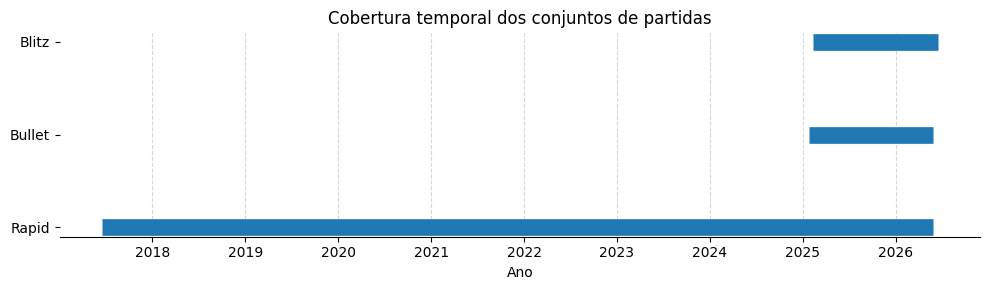

In [3]:
# Datas inicial e final por modalidade
periodos = (
    df.groupby("time_class")["end_time"]
      .agg(inicio="min", fim="max")
      .sort_values("inicio")
)

# Criar figura
fig, ax = plt.subplots(figsize=(10, 3))

# Desenhar uma linha para cada modalidade
for i, (game_mode, row) in enumerate(periodos.iterrows()):
    ax.hlines(
        y=i,
        xmin=row["inicio"],
        xmax=row["fim"],
        linewidth=12,
        label=game_mode.capitalize()
    )

# Eixo Y
ax.set_yticks(range(len(periodos)))
ax.set_yticklabels([m.capitalize() for m in periodos.index])

# Eixo X
ax.set_xlabel("Ano")
ax.set_title("Cobertura temporal dos conjuntos de partidas")
ax.grid(axis="x", linestyle="--", alpha=0.5)

# Remover bordas desnecessárias
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

A cobertura temporal confirma a diferença observada na coleta. Bullet e blitz concentram partidas em uma janela bem mais recente, enquanto rapid precisou voltar até 2017 para tentar alcançar o volume esperado.

Isso sugere que, entre os top players analisados, partidas rapid online rated são menos frequentes do que partidas bullet e blitz. Também é um alerta metodológico: comparar modalidades não significa comparar exatamente o mesmo recorte temporal.


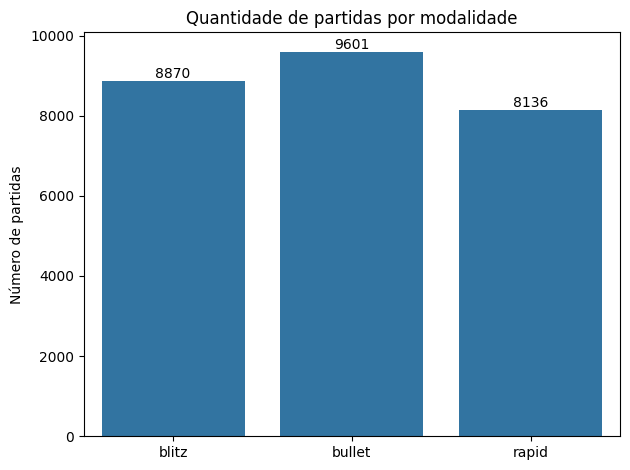

In [4]:
# DF temporário para a contagem das partidas
df_count = (
    df.groupby("time_class")["time_class"]
      .count()
      .reset_index(name="match_count")
)

# Criar figura
ax = sns.barplot(
    data=df_count,
    x="time_class",
    y="match_count"
)

ax.set_title("Quantidade de partidas por modalidade")
ax.set_xlabel("")
ax.set_ylabel("Número de partidas")

# Mostrar o valor acima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

O gráfico de barras mostra o volume final disponível por modalidade em relação ao alvo teórico de 10.000 partidas, considerando 200 partidas para cada um dos 50 jogadores.

- Rapid ficou com 8.136 partidas. Mesmo buscando em uma janela de aproximadamente 9 anos, alguns jogadores não tinham 200 partidas disponíveis.
- Bullet ficou com 9.601 partidas e blitz com 8.870 partidas. As duas modalidades chegaram mais perto do alvo, mas também tiveram casos em que o total por jogador ficou abaixo de 200.

Essa diferença de volume deve ser considerada nas próximas análises. Sempre que possível, percentuais ajudam mais do que contagens absolutas para comparar modalidades com tamanhos diferentes.


### 2. Quais eventos aparecem no dataset?

Aqui verifico se as partidas vieram apenas de jogos comuns do Live Chess ou se há outros tipos de evento, como torneios. Essa checagem ajuda a entender se o dataset mistura contextos competitivos diferentes.


In [5]:
# Extrair o nome do evento com um regex dos valores do pgn
df["event"] = df["pgn"].str.extract(r'\[Event\s+"([^"]+)"\]')
df.groupby("time_class")["event"].value_counts()

time_class  event     
blitz       Live Chess    8870
bullet      Live Chess    9601
rapid       Live Chess    8136
Name: count, dtype: int64

Todas as partidas aparecem como `Live Chess`. Como o processamento anterior já filtrou partidas rated e regras padrão de xadrez, o dataset fica mais homogêneo para comparar modalidades.

Mesmo assim, vale manter essa validação no EDA, porque ela documenta uma premissa importante da amostra: os resultados analisados vêm de partidas online rated no ambiente padrão do Chess.com.


### 3. Em média, quantos lances têm as partidas por modalidade?

A quantidade de lances ajuda a caracterizar o tipo de partida em cada modalidade. A expectativa inicial poderia ser que partidas mais rápidas terminassem mais cedo, mas isso precisa ser verificado nos dados.

Neste notebook, a contagem usa o número de jogadas completas extraído do PGN com `python-chess`.


In [6]:
# Extrair a quantidade de lances totais, usando python-chess para percorrer o pgn
def get_num_moves_chess(pgn):
    game = chess.pgn.read_game(io.StringIO(pgn))
    return game.end().board().fullmove_number - (
        1 if game.end().board().turn == chess.WHITE else 0
    )

df["moves_count"] = df["pgn"].apply(get_num_moves_chess)

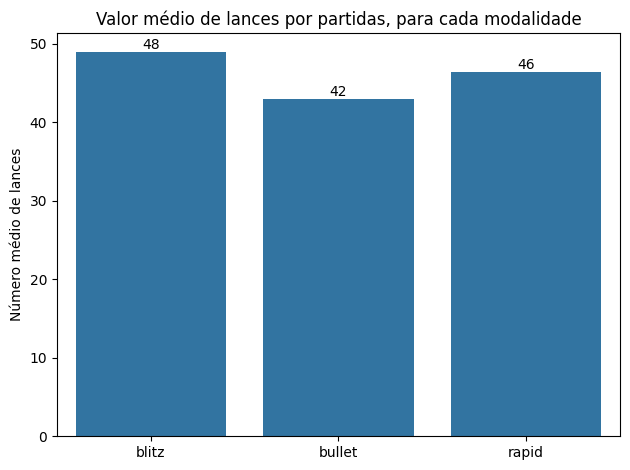

In [ ]:
# DF temporário para a média de lances
df_mean_moves = (
    df.groupby("time_class")["moves_count"]
        .agg("mean")
        .reset_index(name="moves_mean")
)

# Criar figura
ax = sns.barplot(
    data=df_mean_moves,
    x="time_class",
    y="moves_mean"
)

ax.set_title("Valor médio de lances por partidas, para cada modalidade")
ax.set_xlabel("")
ax.set_ylabel("Número médio de lances")

# Mostrar o valor acima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

As médias ficaram próximas entre as modalidades. Isso indica que, nesta amostra, a duração da partida em número de jogadas completas não muda muito entre bullet, blitz e rapid.

Essa conclusão deve ser lida junto com a distribuição, porque médias parecidas podem esconder caudas longas ou muitos outliers.


### 4. Como é a distribuição da quantidade de lances?

Depois de olhar a média, faz sentido analisar a distribuição completa. O boxplot e o histograma ajudam a ver dispersão e assimetria.

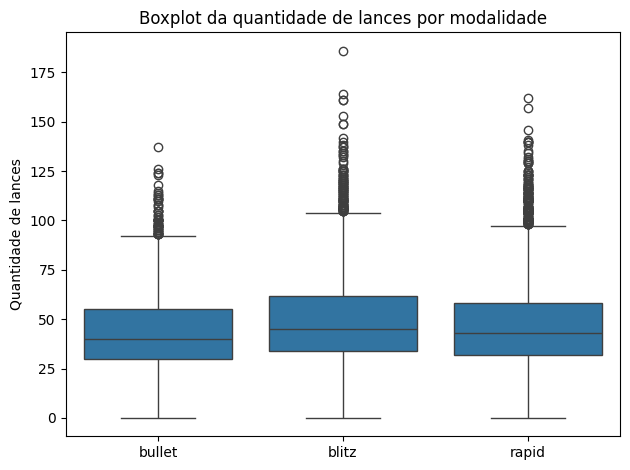

In [ ]:
# Criar figura
ax = sns.boxplot(
    data=df,
    x="time_class",
    y="moves_count"
)

ax.set_title("Boxplot da quantidade de lances por modalidade")
ax.set_xlabel("")
ax.set_ylabel("Quantidade de lances")

plt.tight_layout()
plt.show()

A distribuição também parece relativamente parecida entre as modalidades, mas há muitos outliers com partidas mais longas.

Isso reforça que a média sozinha não descreve bem a variável. Para modelagem, pode valer testar transformações, cortes ou variáveis derivadas caso `moves_count` seja usado como feature.


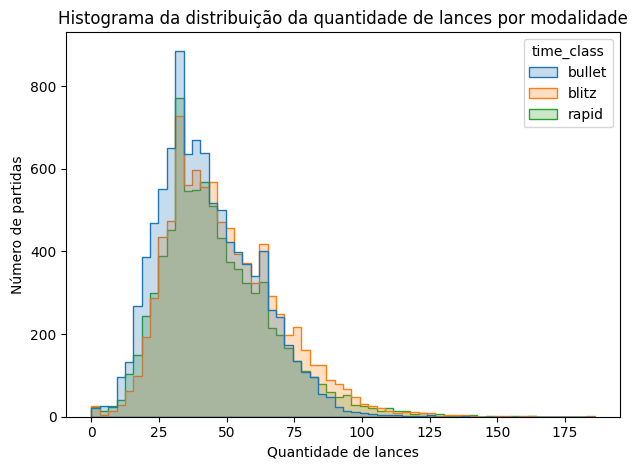

In [ ]:
# Criar figura
ax = sns.histplot(
    data=df,
    x="moves_count",
    hue="time_class",
    element="step",
    stat="count",
    bins=60
)

ax.set_title("Histograma da distribuição da quantidade de lances por modalidade")
ax.set_xlabel("Quantidade de lances")
ax.set_ylabel("Número de partidas")

plt.tight_layout()
plt.show()

O histograma mostra assimetria positiva: a maior parte das partidas se concentra em valores menores ou intermediários, com uma cauda à direita formada por partidas longas.

Essa cauda explica os outliers vistos no boxplot e sugere que mediana e quartis podem ser medidas mais informativas do que apenas a média.


### 5. Quais controles de tempo são mais frequentes?

Esta análise mostra quais configurações de tempo aparecem dentro de cada modalidade. Isso é relevante porque `time_class` resume a categoria, mas partidas dentro da mesma categoria podem ter controles diferentes.


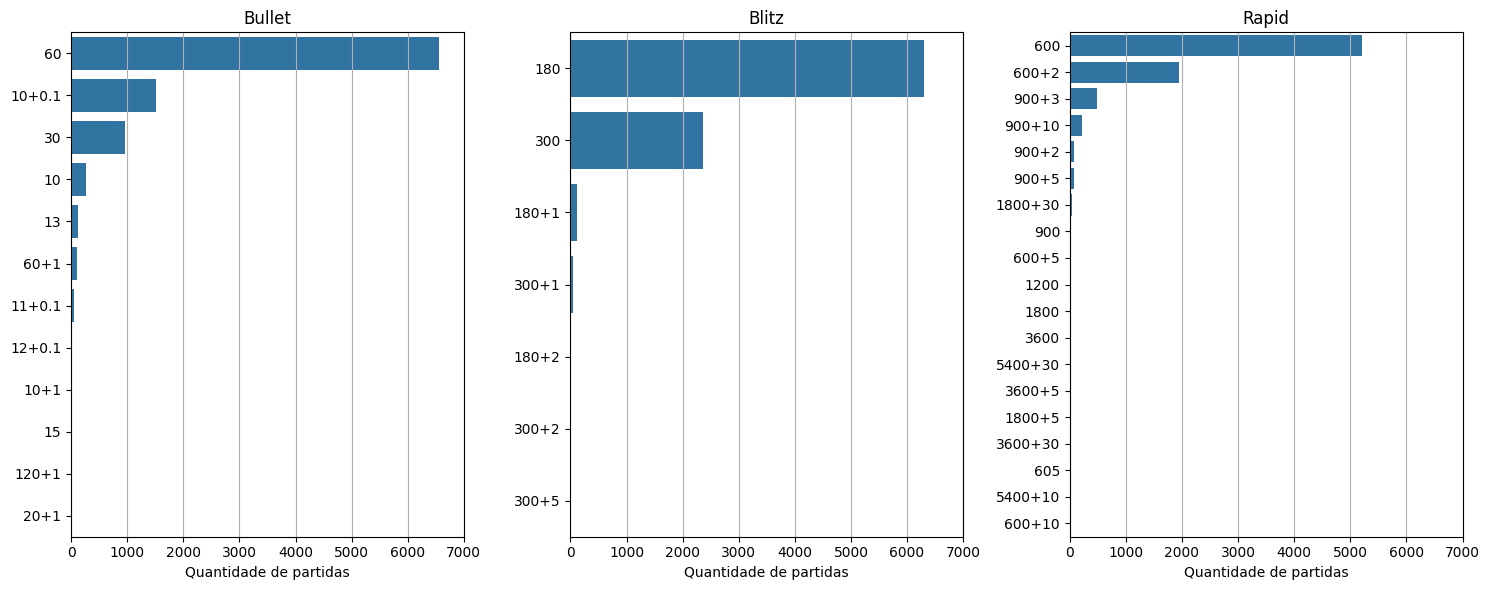

In [201]:
# DF de frequência dos controle de tempo
df_freq_time = (
    df.groupby("time_class")["time_control"]
      .value_counts()
      .reset_index(name="count")
)

# Criação da figura
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

time_classes = ["bullet", "blitz", "rapid"]

# Plotar os três gráficos
for ax, time_class in zip(axes, time_classes):

    dados = (
        df_freq_time[df_freq_time["time_class"] == time_class]
        .sort_values("count", ascending=False)
    )

    sns.barplot(
        data=dados,
        x="count",
        y="time_control",
        ax=ax
    )

    ax.grid(axis='x')
    ax.set_xlim(0, 7000)
    ax.set_title(time_class.capitalize())
    ax.set_xlabel("Quantidade de partidas")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

Os controles mais comuns seguem os padrões esperados: `60` para bullet, `180` para blitz e `600` para rapid.

Rapid apresenta maior variedade de controles de tempo, indo de 600 até 5400 segundos. Isso pode aumentar a heterogeneidade dentro da própria modalidade rapid e deve ser considerado se o modelo usar apenas `time_class` sem olhar para `time_control`.


### 6. Quais foram os motivos de encerramento mais comuns?

O motivo de encerramento ajuda a entender como as partidas terminam em cada modalidade: desistência, tempo, xeque-mate, repetição, acordo ou outros casos. Essa variável também pode indicar diferenças de dinâmica entre partidas rápidas e lentas.


In [ ]:
# Extrair com Regex o termination, da  string pgn das partidas
df['termination_result'] = df['pgn'].str.extract(r'\[Termination "[^"]*\b(\w+)"\]')

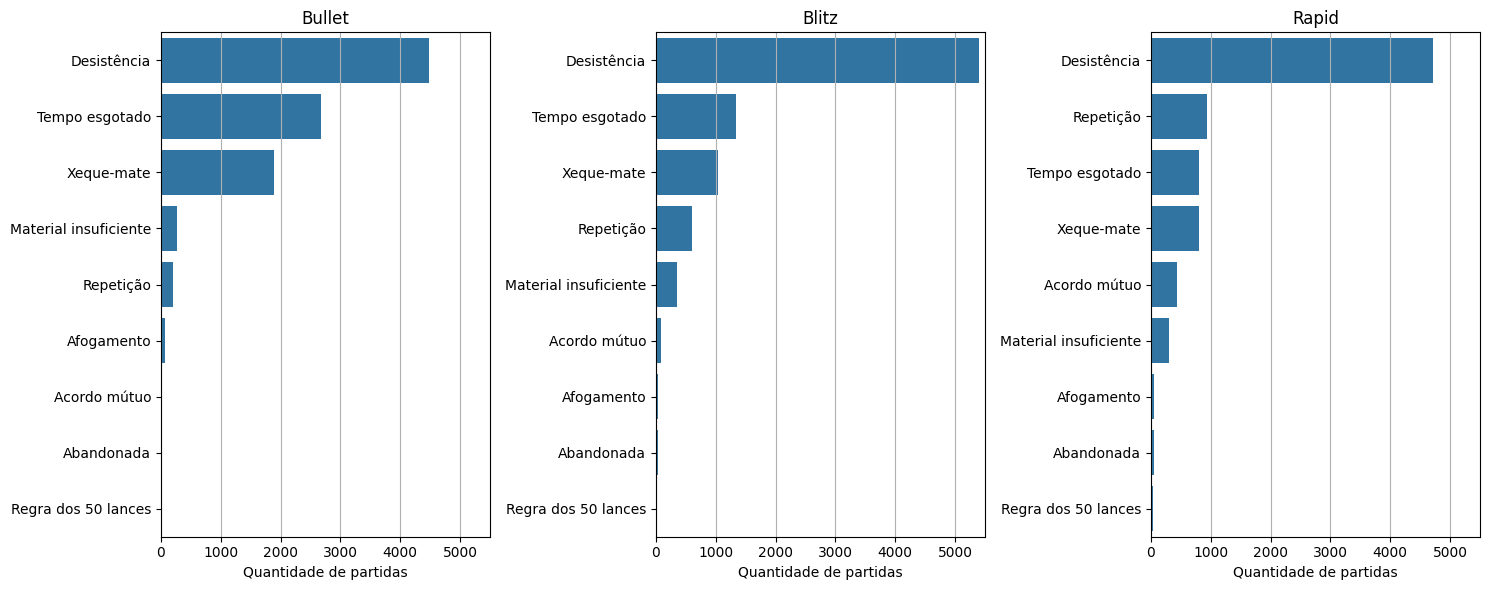

In [208]:
# DF de frequência dos terminations
df_freq_time = (
    df.groupby("time_class")["termination_result"]
      .value_counts()
      .reset_index(name="count")
)

# Criação da figura
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

time_classes = ["bullet", "blitz", "rapid"]

# Plotar os três gráficos
traducoes = {
    'resignation': 'Desistência',
    'time': 'Tempo esgotado',
    'checkmate': 'Xeque-mate',
    'repetition': 'Repetição',
    'material': 'Material insuficiente',
    'agreement': 'Acordo mútuo',
    'stalemate': 'Afogamento',
    'abandoned': 'Abandonada',
    'rule': 'Regra dos 50 lances'
}

for ax, time_class in zip(axes, time_classes):
    dados = (
        df_freq_time[df_freq_time["time_class"] == time_class]
        .sort_values("count", ascending=False)
        .assign(termination_result=lambda x: x["termination_result"].map(traducoes))
    )

    sns.barplot(
        data=dados,
        x="count",
        y="termination_result",
        ax=ax
    )

    ax.grid(axis='x')
    ax.set_xlim(0, 5500)
    ax.set_title(time_class.capitalize())
    ax.set_xlabel("Quantidade de partidas")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

- Desistência é o motivo mais comum de encerramento em todas as modalidades.
- Em bullet, há uma presença relativamente maior de partidas terminando por tempo ou xeque-mate, o que combina com a pressão maior do relógio.
- Bullet e blitz mantêm o mesmo top 3 de encerramentos. Rapid se diferencia porque repetição aparece com mais destaque.


### 7. Qual é a frequência de empates e vitórias?

Aqui as partidas são agrupadas em três categorias: empate, vitória das brancas e vitória das pretas. Essa análise é importante para entender o balanceamento do alvo que será usado em modelagem.


In [175]:
draws = {'repetition', 'agreement', 'stalemate', 'material', 'rule'}

df['is_draw'] = df['termination_result'].isin(draws)
df['white_win'] = df['white'].apply(lambda x: x['result'] == 'win')

# Função que vai adicionar o valor do vencedor (brancas ou pretas) ou empate
def categorize_result(row):
    if row['is_draw']:
        return 'Empate'
    elif row['white_win']:
        return 'Vitória das brancas'
    else:
        return 'Vitória das pretas'

df['result_category'] = df.apply(categorize_result, axis=1)

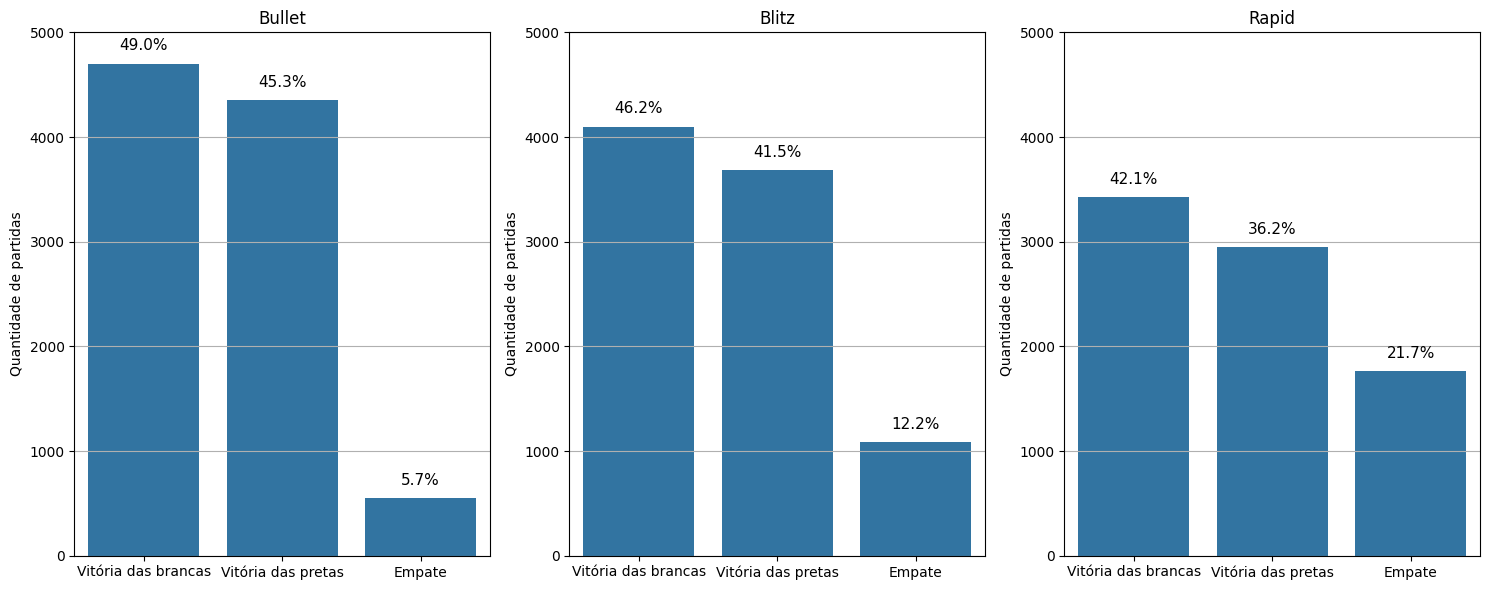

In [198]:
# DF de frequência
df_freq_draw = (
    df.groupby("time_class")["result_category"]
    .value_counts()
    .reset_index(name="count")
)

# Criação da figura
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

time_classes = ["bullet", "blitz", "rapid"]

# Plotar os três gráficos
for ax, time_class in zip(axes, time_classes):
    dados = (
        df_freq_draw[df_freq_draw["time_class"] == time_class]
        .sort_values("count", ascending=False)
    )
    sns.barplot(
        data=dados,
        x="result_category",
        y="count",
        ax=ax
    )
    
    # Valor percentual 
    total = dados["count"].sum()
    for bar in ax.patches:
        pct = bar.get_height() / total * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 100,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=11
        )

    ax.grid(axis='y')
    ax.set_ylim(0, 5000)
    ax.set_title(time_class.capitalize())
    ax.set_xlabel("")
    ax.set_ylabel("Quantidade de partidas")

plt.tight_layout()
plt.show()

O gráfico sugere duas tendências relevantes:

- Quanto maior o tempo de jogo, maior parece ser a proporção de empates.
- Em todas as modalidades, as brancas aparecem com uma pequena vantagem em relação às pretas.

Essas diferenças são importantes para o modelo. Se o alvo for vitória das brancas contra vitória das pretas, empates precisam ser tratados explicitamente: removidos ou mantidos como terceira classe.


### 8. Com que frequência o jogador de maior rating venceu?

Esta análise aproxima a hipótese central do projeto. Se o rating tiver poder preditivo, o jogador com maior rating deve vencer mais vezes do que o jogador com menor rating.

Empates e partidas com ratings iguais são removidos desta comparação, porque nesses casos não há um vencedor favorito claro pela diferença de rating.


In [205]:
# Colunas com os ratings da Brancas e das Pretas
df['white_rating'] = df['white'].apply(lambda x: x['rating'])
df['black_rating'] = df['black'].apply(lambda x: x['rating'])

# Coluna booleana, True se o maior rating ganhou
df['higher_rated_won'] = (
    (df['white_rating'] > df['black_rating']) & df['white_win']
) | (
    (df['black_rating'] > df['white_rating']) & ~df['white_win'] & ~df['is_draw']
)

# Mesmo rating
df['same_rating'] = df['white_rating'] == df['black_rating']

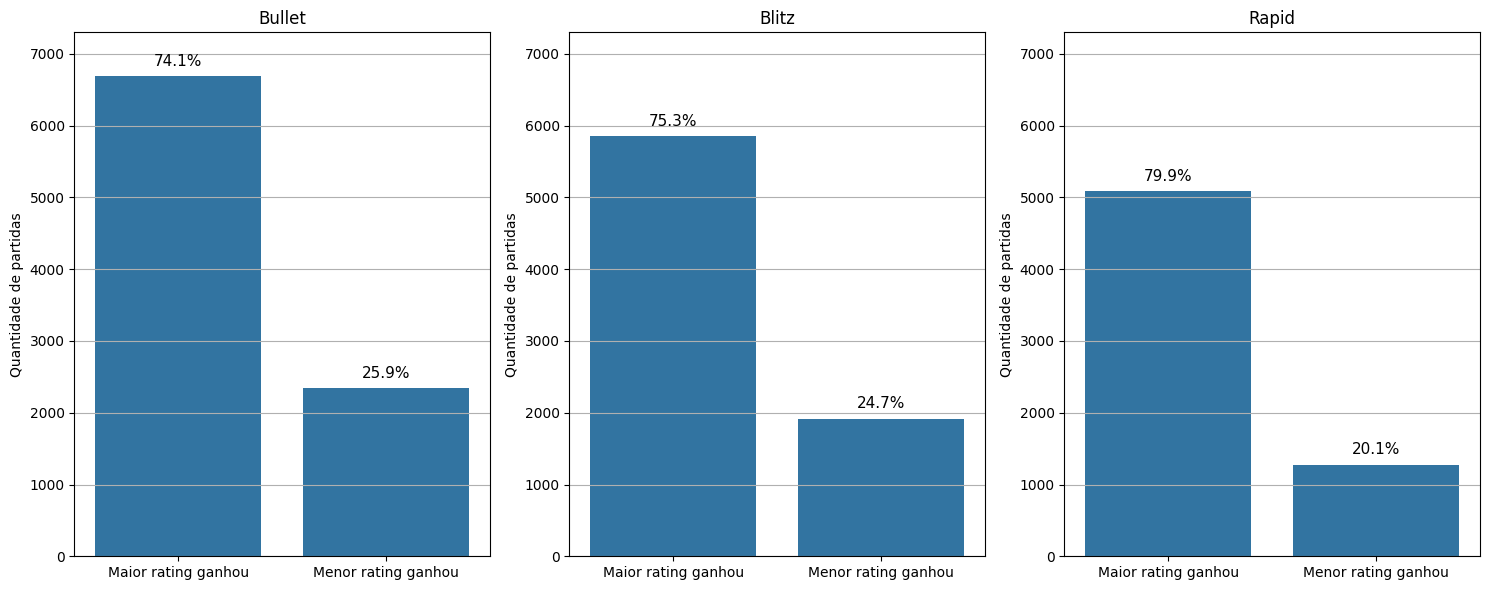

In [ ]:
# Excluir os empates e mesmos ratings da análise
df_no_draw = df[~df['is_draw'] & ~df['same_rating']]

df_freq_rated = (
    df_no_draw.groupby("time_class")["higher_rated_won"]
    .value_counts()
    .reset_index(name="count")
)

rename = {
    True: "Maior rating ganhou",
    False: "Menor rating ganhou"
}

# Criação da figura
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
time_classes = ["bullet", "blitz", "rapid"]

# Plotar os três gráficos
for ax, time_class in zip(axes, time_classes):
    dados = (
        df_freq_rated[df_freq_rated["time_class"] == time_class]
        .sort_values("count", ascending=False)
        .assign(higher_rated_won=lambda x: x["higher_rated_won"].map(rename))
    )
    sns.barplot(
        data=dados,
        x="higher_rated_won",
        y="count",
        ax=ax
    )

    # Valor percentual 
    total = dados["count"].sum()
    for bar in ax.patches:
        pct = bar.get_height() / total * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 100,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=11
        )

    ax.grid(axis='y')
    ax.set_ylim(0, 7300)
    ax.set_title(time_class.capitalize())
    ax.set_xlabel("")
    ax.set_ylabel("Quantidade de partidas")

plt.tight_layout()
plt.show()

O rating parece ser uma variável forte para modelagem, principalmente entre top players.

- Em todas as modalidades, o jogador com maior rating vence mais vezes do que o jogador com menor rating.
- A vantagem do maior rating parece aumentar conforme o tempo da partida aumenta.
- Esse resultado conversa diretamente com a hipótese do projeto: em partidas mais rápidas, a diferença de rating pode explicar menos o resultado do que em rapid.
